# OOS Trade Deep Dive — 10 Random Trades

Stratified random sample from OOS V1 trades (W3: ESH5→ESM5, W4: ESM5→ESU5): **7 longs, 3 shorts. No seed.**

Each trade is broken down across:
- **T (signal bar)**: what the model saw — spread, FV, deviation, z-score, rolling σ
- **T+1 (fill bar)**: entry price, z at fill, whether HC watch was set
- **T+2 (add-on bar)**: whether the HC add-on fired, blended entry
- **Position structure**: lots, layers, TP/SL levels
- **Exit**: exit type, hold time, MAE/MFE, gross/net P&L
- **Charts**: calendar spread + FV (with entry/exit markers), z-score panel, underlying front/back contract prices


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from IPython.display import display
import warnings, os
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#f8f9fa",
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 8.5,
})

MBP_DIR = "/Volumes/SEAGATE/Databento_Futures"
PROJ    = "/Users/stark/Desktop/Projects/Futures_RollOver"
TC = 8.04; N_LOTS = 10; Z_SIG = 2.0; Z_HC = 3.0

OOS = {
    "W3": dict(wdir=f"{PROJ}/results/ESH5_ESM5_20250313", pair="ESH5_ESM5",
               roll_start="2025-03-13", front="ESH5", back="ESM5",
               label="ESH5->ESM5 (Mar-25 roll)"),
    "W4": dict(wdir=f"{PROJ}/results/ESM5_ESU5_20250612", pair="ESM5_ESU5",
               roll_start="2025-06-12", front="ESM5", back="ESU5",
               label="ESM5->ESU5 (Jun-25 roll)"),
}
ALL_SESS = ["European_Ungated", "European_V1", "US_RTH_Ungated",
            "US_RTH_V1", "Post_close_Ungated", "Post_close_V1"]

_ts_cache  = {}
_mbp_cache = {}


def load_ts(wdir, slabel):
    k = (wdir, slabel)
    if k not in _ts_cache:
        _ts_cache[k] = pd.read_parquet(f"{wdir}/{slabel}/timeseries.parquet")
    return _ts_cache[k]


def load_mbp(pair, roll_start, date_str):
    k = (pair, date_str)
    if k not in _mbp_cache:
        path = f"{MBP_DIR}/mbp10_{pair}_{roll_start}_{date_str}.parquet"
        print(f"  Loading {os.path.basename(path)} ...", end=" ", flush=True)
        df = pd.read_parquet(path, columns=["bid_px_00", "ask_px_00", "symbol"])
        df["mid"] = (df["bid_px_00"] + df["ask_px_00"]) / 2
        fs, bs = pair.split("_")
        _mbp_cache[k] = dict(
            front=df[df["symbol"] == fs]["mid"].resample("1s").last().ffill(),
            back =df[df["symbol"] == bs]["mid"].resample("1s").last().ffill(),
            fs=fs, bs=bs,
        )
        print("done.")
    return _mbp_cache[k]


def lvcf(series, t):
    # Last valid observation at or before second-floor of t.
    sub = series.loc[: t.floor("1s")]
    return float(sub.iloc[-1]) if len(sub) else np.nan


def ts_at(ts_df, t):
    # Timeseries row at exact second t (floor); nearest prior if not present.
    t_s = t.floor("1s")
    if t_s in ts_df.index:
        return ts_df.loc[t_s]
    sub = ts_df.loc[:t_s]
    return sub.iloc[-1] if len(sub) else None


print("Setup complete.")


Setup complete.


In [2]:
dfs = []
for wk, wi in OOS.items():
    for sl in ALL_SESS:
        p = f"{wi['wdir']}/{sl}/trades.parquet"
        if not os.path.exists(p):
            continue
        df = pd.read_parquet(p)
        df["window"]     = wk
        df["session"]    = sl.rsplit("_", 1)[0]
        df["gate"]       = sl.rsplit("_", 1)[1]
        df["sess_label"] = sl
        df["wdir"]       = wi["wdir"]
        df["pair"]       = wi["pair"]
        df["roll_start"] = wi["roll_start"]
        dfs.append(df)

all_oos = pd.concat(dfs, ignore_index=True)

# Keep V1 gate only, no deduplication needed (V1 is unique per session).
pool = all_oos[all_oos["gate"] == "V1"].reset_index(drop=True)

longs  = pool[pool["direction"] ==  1]
shorts = pool[pool["direction"] == -1]

sample = pd.concat([
    longs.sample(7),
    shorts.sample(3),
]).sample(frac=1).reset_index(drop=True)   # shuffle order

print(f"V1 pool: {len(longs)} longs, {len(shorts)} shorts  ->  sampled 7L + 3S")
display(sample[["window", "session", "gate", "entry_time", "dir_label",
                "entry_z", "hc_addon", "exit_type", "gross_usd"]].reset_index(drop=True))


V1 pool: 258 longs, 41 shorts  ->  sampled 7L + 3S


,window,session,gate,entry_time,dir_label,entry_z,hc_addon,exit_type,gross_usd
0,W4,European,V1,2025-06-16 07:31:05+00:00,Long,-1.431518,False,TP,12.50
1,W3,European,V1,2025-03-14 10:23:17+00:00,Short,3.138424,True,EOD,0.00
2,W3,US_RTH,V1,2025-03-18 16:29:42+00:00,Short,0.222528,False,TP,12.50
3,W3,US_RTH,V1,2025-03-13 12:46:09+00:00,Long,-1.681325,False,TP,12.50
4,W4,European,V1,2025-06-13 07:56:12+00:00,Long,-3.894425,True,SL,47.50
5,W3,US_RTH,V1,2025-03-13 17:30:13+00:00,Long,-2.182267,False,SL,23.75
6,W4,US_RTH,V1,2025-06-13 14:23:01+00:00,Long,-1.936658,False,TP,12.50
7,W3,US_RTH,V1,2025-03-18 14:35:15+00:00,Long,-2.145549,False,SL,23.75
8,W4,European,V1,2025-06-12 12:03:40+00:00,Long,-1.439342,False,TP,12.50
9,W3,US_RTH,V1,2025-03-17 13:31:48+00:00,Short,1.869587,False,TP,12.50


  Loading mbp10_ESM5_ESU5_2025-06-12_2025-06-16.parquet ... 

done.

  TRADE 1/10  |  W4: ESM5->ESU5 (Jun-25 roll)
  Session: European  |  Gate: V1  |  2025-06-16 Monday

  T   (SIGNAL BAR)   07:31:04 UTC
  Spread          52.6250 pts
  Fair Value      45.2418 pts
  Deviation       +7.3832 pts  (spread - FV)
  Z-score         -2.5005  |  Rolling sigma ~ 2.9526 pts/z-unit
  ESM5          6012.8750    |  ESU5: 6065.5000
  --> Signal FIRES: z=-2.50 exceeds -2.0
      LONG: spread is +7.3832 pts (-2.5 sigma) BELOW fair value.
      Model expects mean-reversion upward.

  T+1 (FILL BAR)     07:31:05 UTC
  Entry spread      52.7500 pts  (midprice at T+1 bar)
  Z at fill         -1.4315
  ESM5            6012.6250    |  ESU5: 6065.3750
  --> ENTERED LONG at 52.7500  (10 lots)
  Market order executed at T+1 midprice.  (drift gate ALLOWED this direction)
  Low-z trade: |entry_z|=1.43 < 2.0  ->  single layer 100% TP at +0.25 pts; SL at -0.50 pts
  Not HC: |z_fill|=1.43 <= 3.0  ->  no add-on watch

  T+2 (ADD-ON BAR)   07:31:06 UTC
  Not applicable (HC watc

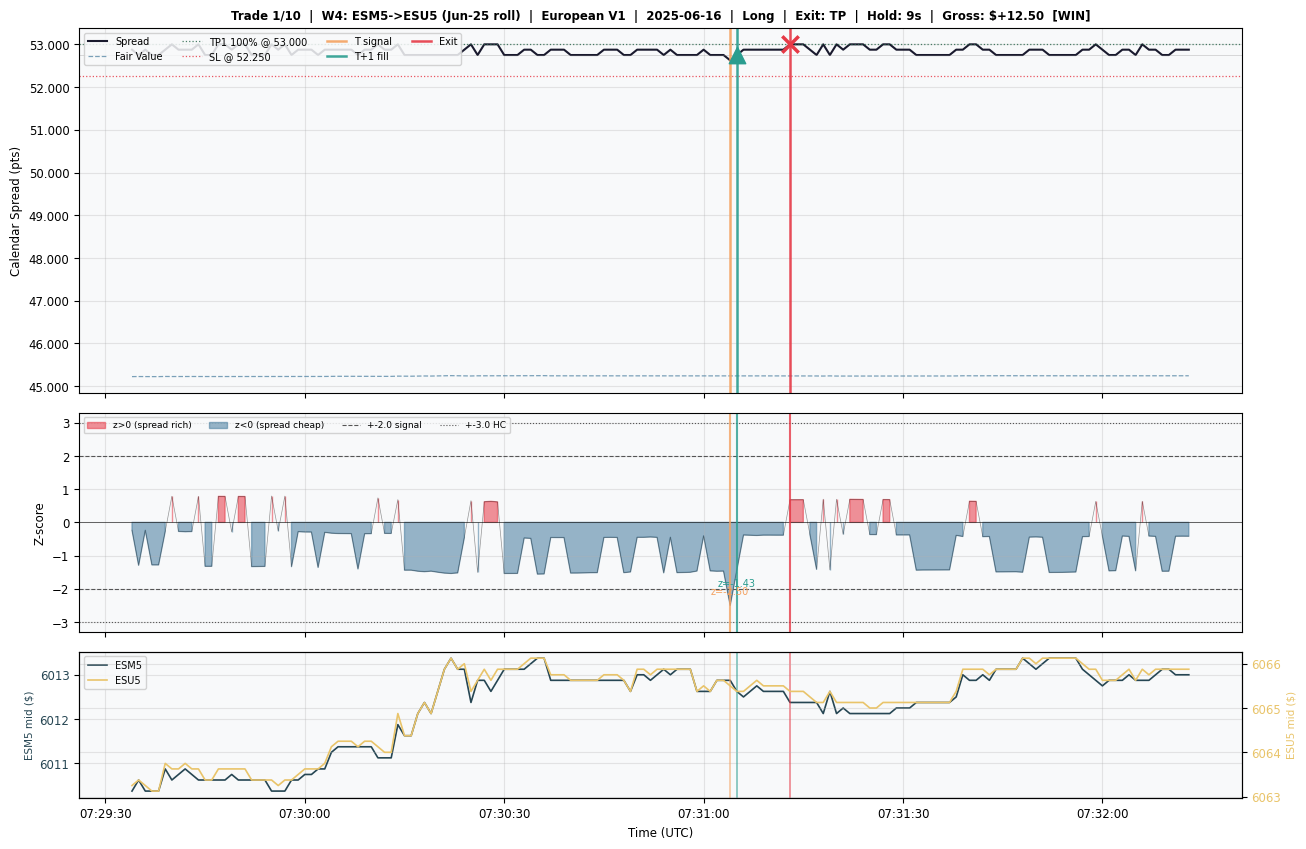


  Loading mbp10_ESH5_ESM5_2025-03-13_2025-03-14.parquet ... 

done.

  TRADE 2/10  |  W3: ESH5->ESM5 (Mar-25 roll)
  Session: European  |  Gate: V1  |  2025-03-14 Friday

  T   (SIGNAL BAR)   10:23:16 UTC
  Spread          51.2500 pts
  Fair Value      41.5900 pts
  Deviation       +9.6600 pts  (spread - FV)
  Z-score         +3.1701  |  Rolling sigma ~ 3.0472 pts/z-unit
  ESH5          5564.3750    |  ESM5: 5615.6250
  --> Signal FIRES: z=+3.17 exceeds +2.0
      SHORT: spread is +9.6600 pts (+3.2 sigma) ABOVE fair value.
      Model expects mean-reversion downward.

  T+1 (FILL BAR)     10:23:17 UTC
  Entry spread      51.2500 pts  (midprice at T+1 bar)
  Z at fill         +3.1384
  ESH5            5564.3750    |  ESM5: 5615.6250
  --> ENTERED SHORT at 51.2500  (20 lots)
  Market order executed at T+1 midprice.  (drift gate ALLOWED this direction)
  Standard-z: |entry_z|=3.14 >= 2.0  ->  two-layer exit (90%@+0.50, 10%@+0.75)
  HC WATCH SET: |z_fill|=3.14 > 3.0  ->  checking T+2 bar

  T+2 (ADD-ON BAR)   10:23:18 UTC
  Z at T+2:  +3.1075
  |z|=3

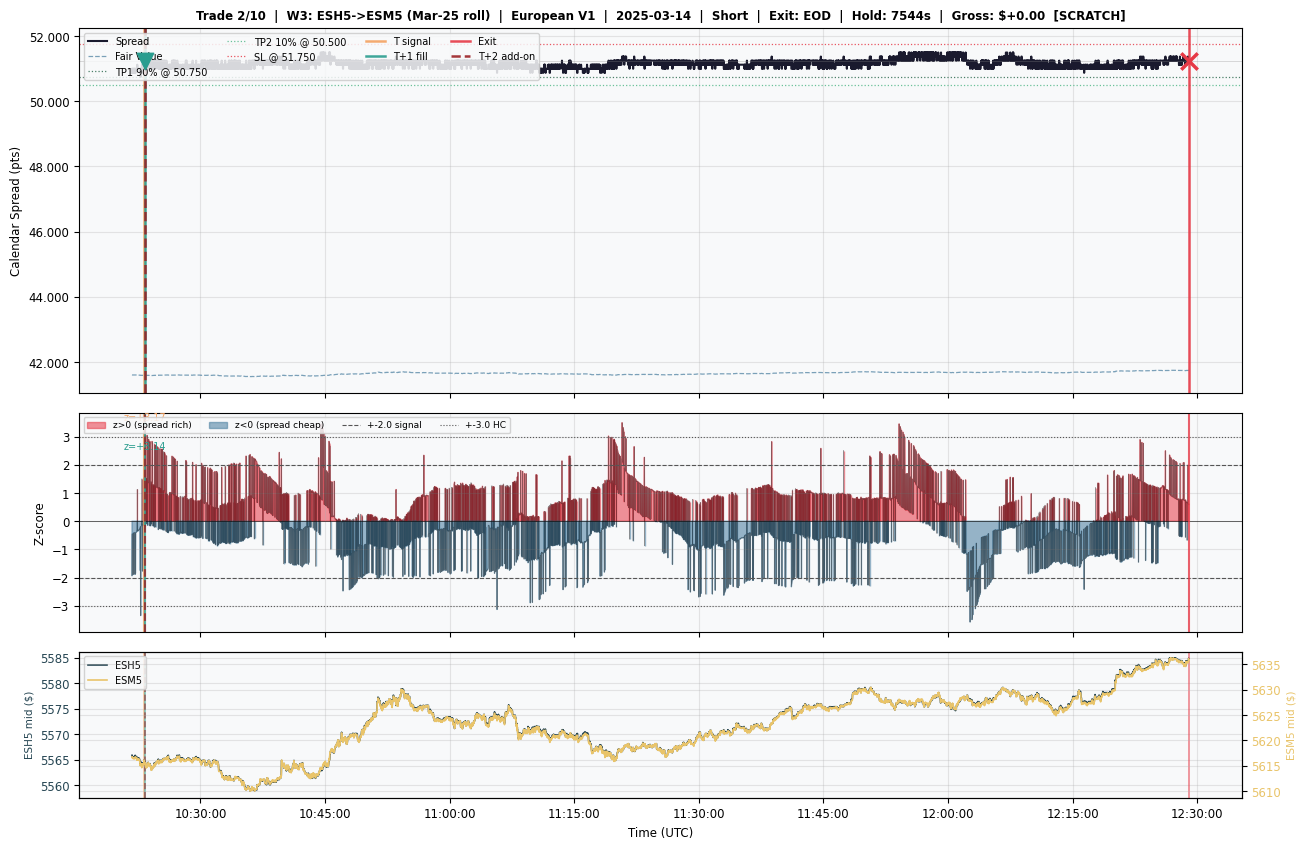


  Loading mbp10_ESH5_ESM5_2025-03-13_2025-03-18.parquet ... 

done.

  TRADE 3/10  |  W3: ESH5->ESM5 (Mar-25 roll)
  Session: US_RTH  |  Gate: V1  |  2025-03-18 Tuesday

  T   (SIGNAL BAR)   16:29:41 UTC
  Spread          51.5000 pts
  Fair Value      42.1786 pts
  Deviation       +9.3214 pts  (spread - FV)
  Z-score         +2.7995  |  Rolling sigma ~ 3.3296 pts/z-unit
  ESH5          5624.3750    |  ESM5: 5675.8750
  --> Signal FIRES: z=+2.80 exceeds +2.0
      SHORT: spread is +9.3214 pts (+2.8 sigma) ABOVE fair value.
      Model expects mean-reversion downward.

  T+1 (FILL BAR)     16:29:42 UTC
  Entry spread      51.2500 pts  (midprice at T+1 bar)
  Z at fill         +0.2225
  ESH5            5624.6250    |  ESM5: 5675.8750
  --> ENTERED SHORT at 51.2500  (10 lots)
  Market order executed at T+1 midprice.  (drift gate ALLOWED this direction)
  Low-z trade: |entry_z|=0.22 < 2.0  ->  single layer 100% TP at +0.25 pts; SL at -0.50 pts
  Not HC: |z_fill|=0.22 <= 3.0  ->  no add-on watch

  T+2 (ADD-ON BAR)   16:29:43 UTC
  Not applicable (HC w

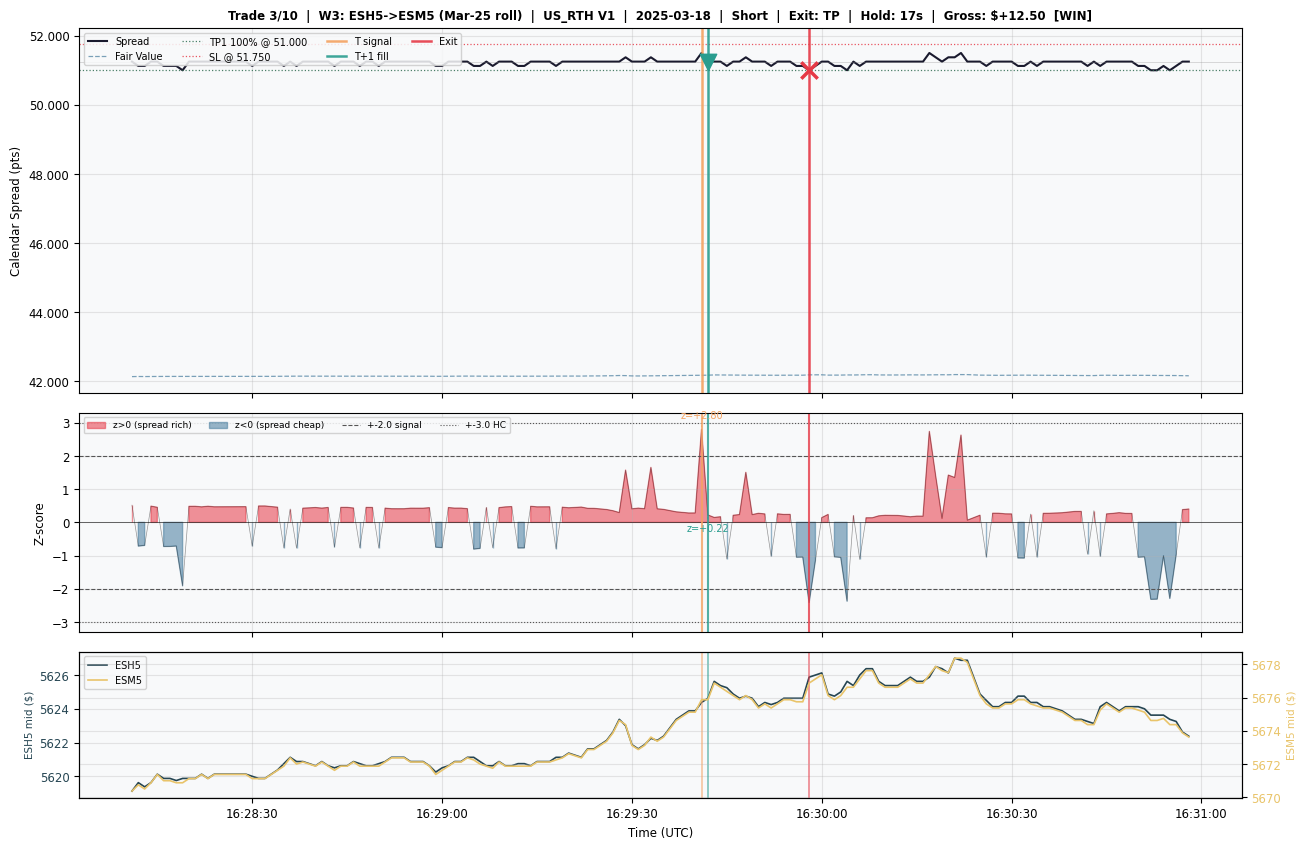


  Loading mbp10_ESH5_ESM5_2025-03-13_2025-03-13.parquet ... 

done.

  TRADE 4/10  |  W3: ESH5->ESM5 (Mar-25 roll)
  Session: US_RTH  |  Gate: V1  |  2025-03-13 Thursday

  T   (SIGNAL BAR)   12:46:08 UTC
  Spread          51.3750 pts
  Fair Value      41.7656 pts
  Deviation       +9.6094 pts  (spread - FV)
  Z-score         -2.5614  |  Rolling sigma ~ 3.7516 pts/z-unit
  ESH5          5587.8750    |  ESM5: 5639.2500
  --> Signal FIRES: z=-2.56 exceeds -2.0
      LONG: spread is +9.6094 pts (-2.6 sigma) BELOW fair value.
      Model expects mean-reversion upward.

  T+1 (FILL BAR)     12:46:09 UTC
  Entry spread      51.5000 pts  (midprice at T+1 bar)
  Z at fill         -1.6813
  ESH5            5587.8750    |  ESM5: 5639.3750
  --> ENTERED LONG at 51.5000  (10 lots)
  Market order executed at T+1 midprice.  (drift gate ALLOWED this direction)
  Low-z trade: |entry_z|=1.68 < 2.0  ->  single layer 100% TP at +0.25 pts; SL at -0.50 pts
  Not HC: |z_fill|=1.68 <= 3.0  ->  no add-on watch

  T+2 (ADD-ON BAR)   12:46:10 UTC
  Not applicable (HC watc

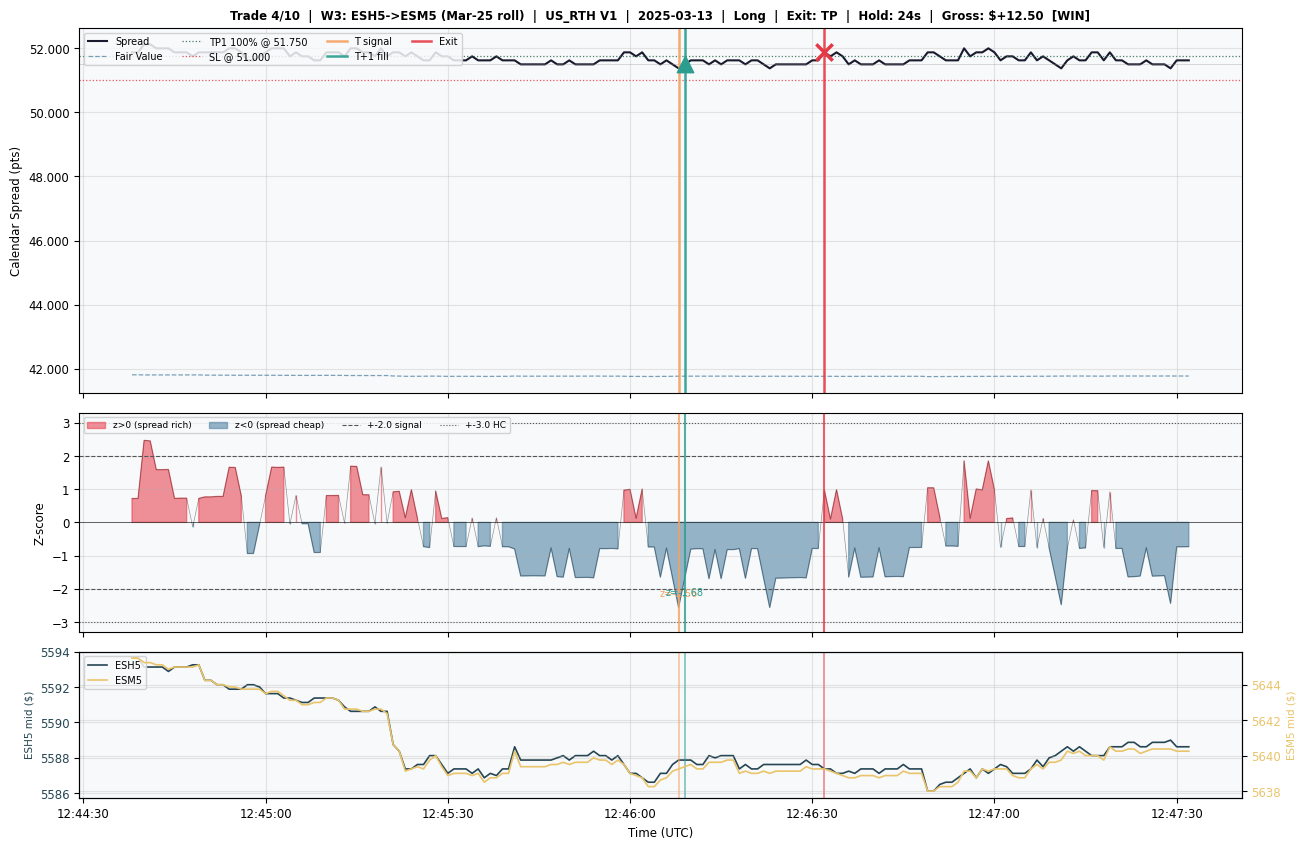


  Loading mbp10_ESM5_ESU5_2025-06-12_2025-06-13.parquet ... 

done.

  TRADE 5/10  |  W4: ESM5->ESU5 (Jun-25 roll)
  Session: European  |  Gate: V1  |  2025-06-13 Friday

  T   (SIGNAL BAR)   07:56:11 UTC
  Spread          52.1250 pts
  Fair Value      44.3512 pts
  Deviation       +7.7738 pts  (spread - FV)
  Z-score         -2.7580  |  Rolling sigma ~ 2.8186 pts/z-unit
  ESM5          5973.6250    |  ESU5: 6025.7500
  --> Signal FIRES: z=-2.76 exceeds -2.0
      LONG: spread is +7.7738 pts (-2.8 sigma) BELOW fair value.
      Model expects mean-reversion upward.

  T+1 (FILL BAR)     07:56:12 UTC
  Entry spread      52.0000 pts  (midprice at T+1 bar)
  Z at fill         -3.8944
  ESM5            5973.8750    |  ESU5: 6025.8750
  --> ENTERED LONG at 52.0000  (20 lots)
  Market order executed at T+1 midprice.  (drift gate ALLOWED this direction)
  Standard-z: |entry_z|=3.89 >= 2.0  ->  two-layer exit (90%@+0.50, 10%@+0.75)
  HC WATCH SET: |z_fill|=3.89 > 3.0  ->  checking T+2 bar

  T+2 (ADD-ON BAR)   07:56:13 UTC
  Z at T+2:  -3.8235
  |z|=3.82 

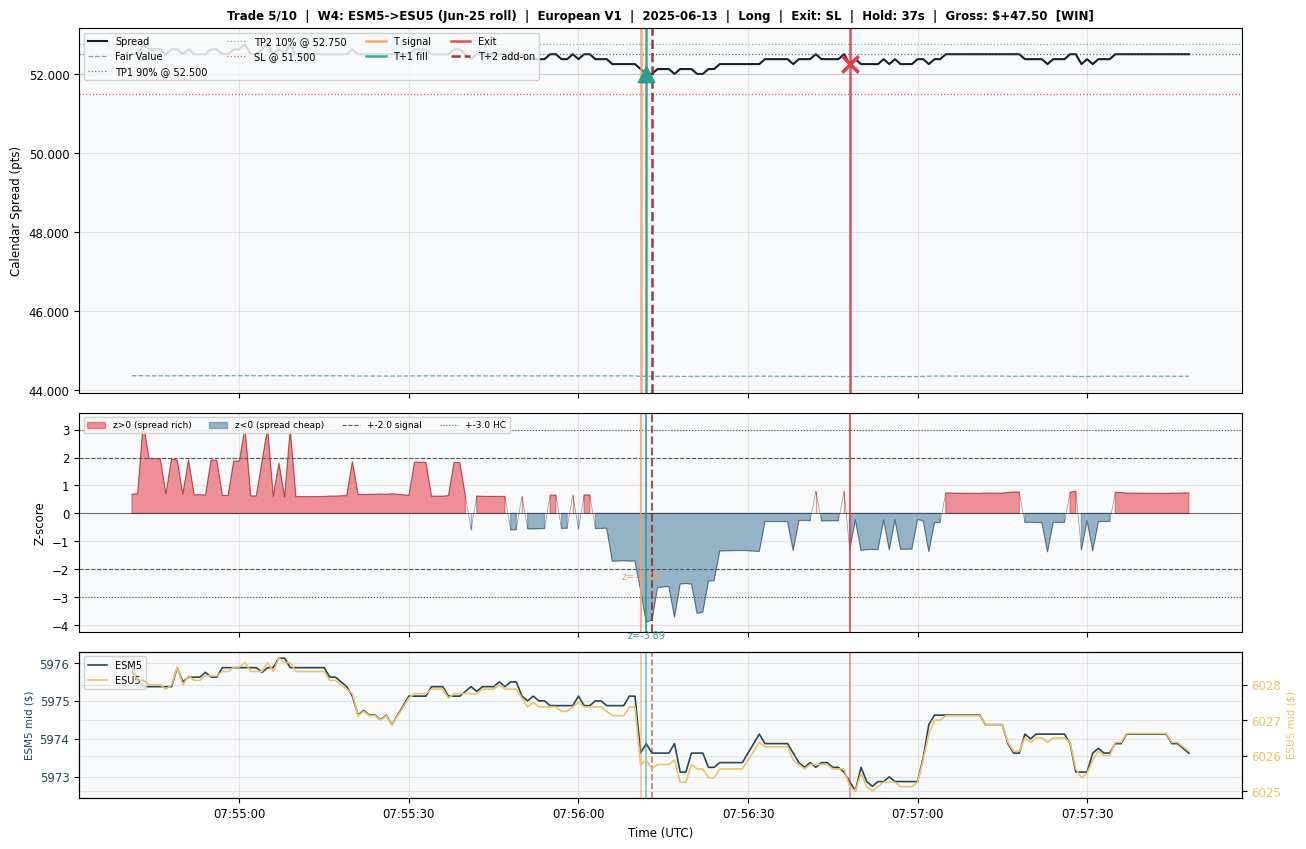



  TRADE 6/10  |  W3: ESH5->ESM5 (Mar-25 roll)
  Session: US_RTH  |  Gate: V1  |  2025-03-13 Thursday

  T   (SIGNAL BAR)   17:30:12 UTC
  Spread          50.2500 pts
  Fair Value      41.2761 pts
  Deviation       +8.9739 pts  (spread - FV)
  Z-score         -3.5457  |  Rolling sigma ~ 2.5309 pts/z-unit
  ESH5          5522.3750    |  ESM5: 5572.6250
  --> Signal FIRES: z=-3.55 exceeds -2.0
      LONG: spread is +8.9739 pts (-3.5 sigma) BELOW fair value.
      Model expects mean-reversion upward.

  T+1 (FILL BAR)     17:30:13 UTC
  Entry spread      50.3750 pts  (midprice at T+1 bar)
  Z at fill         -2.1823
  ESH5            5522.6250    |  ESM5: 5573.0000
  --> ENTERED LONG at 50.3750  (10 lots)
  Market order executed at T+1 midprice.  (drift gate ALLOWED this direction)
  Standard-z: |entry_z|=2.18 >= 2.0  ->  two-layer exit (90%@+0.50, 10%@+0.75)
  Not HC: |z_fill|=2.18 <= 3.0  ->  no add-on watch

  T+2 (ADD-ON BAR)   17:30:14 UTC
  Not applicable (HC watch was not set at T

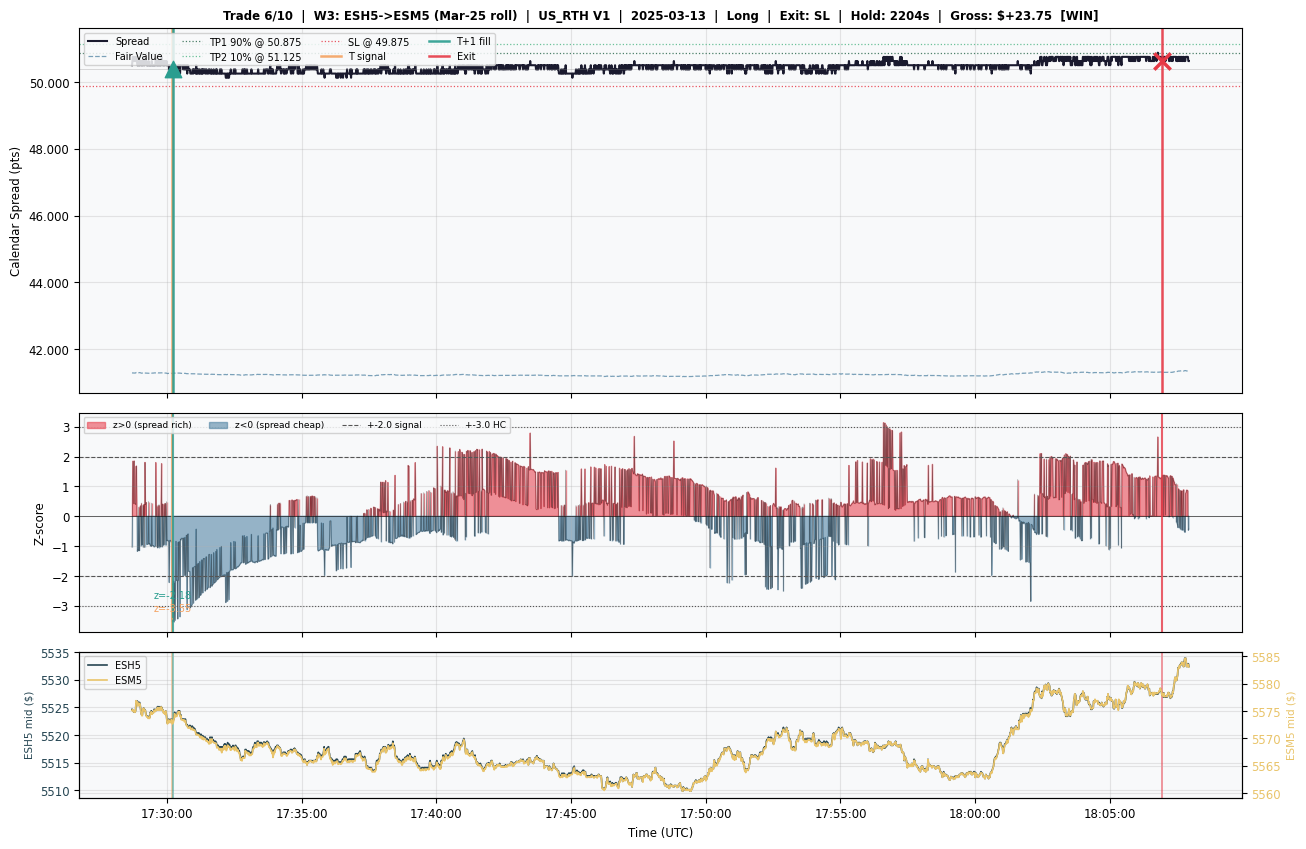



  TRADE 7/10  |  W4: ESM5->ESU5 (Jun-25 roll)
  Session: US_RTH  |  Gate: V1  |  2025-06-13 Friday

  T   (SIGNAL BAR)   14:23:00 UTC
  Spread          52.2500 pts
  Fair Value      44.4366 pts
  Deviation       +7.8134 pts  (spread - FV)
  Z-score         -3.4787  |  Rolling sigma ~ 2.2461 pts/z-unit
  ESM5          5985.1250    |  ESU5: 6037.3750
  --> Signal FIRES: z=-3.48 exceeds -2.0
      LONG: spread is +7.8134 pts (-3.5 sigma) BELOW fair value.
      Model expects mean-reversion upward.

  T+1 (FILL BAR)     14:23:01 UTC
  Entry spread      52.3750 pts  (midprice at T+1 bar)
  Z at fill         -1.9367
  ESM5            5985.1250    |  ESU5: 6037.5000
  --> ENTERED LONG at 52.3750  (10 lots)
  Market order executed at T+1 midprice.  (drift gate ALLOWED this direction)
  Low-z trade: |entry_z|=1.94 < 2.0  ->  single layer 100% TP at +0.25 pts; SL at -0.50 pts
  Not HC: |z_fill|=1.94 <= 3.0  ->  no add-on watch

  T+2 (ADD-ON BAR)   14:23:02 UTC
  Not applicable (HC watch was n

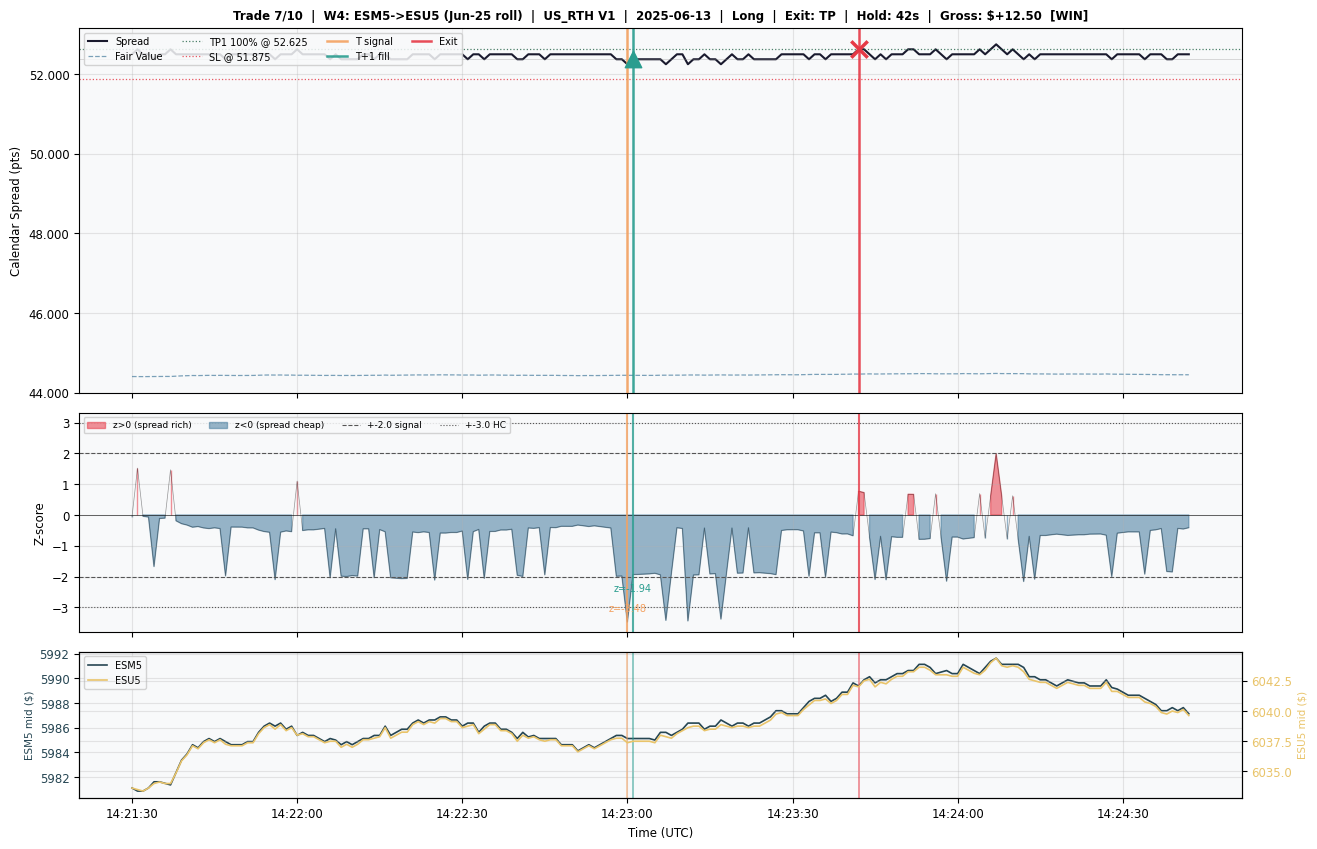



  TRADE 8/10  |  W3: ESH5->ESM5 (Mar-25 roll)
  Session: US_RTH  |  Gate: V1  |  2025-03-18 Tuesday

  T   (SIGNAL BAR)   14:35:14 UTC
  Spread          51.0000 pts
  Fair Value      42.1673 pts
  Deviation       +8.8327 pts  (spread - FV)
  Z-score         -3.3301  |  Rolling sigma ~ 2.6523 pts/z-unit
  ESH5          5622.8750    |  ESM5: 5673.8750
  --> Signal FIRES: z=-3.33 exceeds -2.0
      LONG: spread is +8.8327 pts (-3.3 sigma) BELOW fair value.
      Model expects mean-reversion upward.

  T+1 (FILL BAR)     14:35:15 UTC
  Entry spread      51.1250 pts  (midprice at T+1 bar)
  Z at fill         -2.1455
  ESH5            5622.8750    |  ESM5: 5674.0000
  --> ENTERED LONG at 51.1250  (10 lots)
  Market order executed at T+1 midprice.  (drift gate ALLOWED this direction)
  Standard-z: |entry_z|=2.15 >= 2.0  ->  two-layer exit (90%@+0.50, 10%@+0.75)
  Not HC: |z_fill|=2.15 <= 3.0  ->  no add-on watch

  T+2 (ADD-ON BAR)   14:35:16 UTC
  Not applicable (HC watch was not set at T+

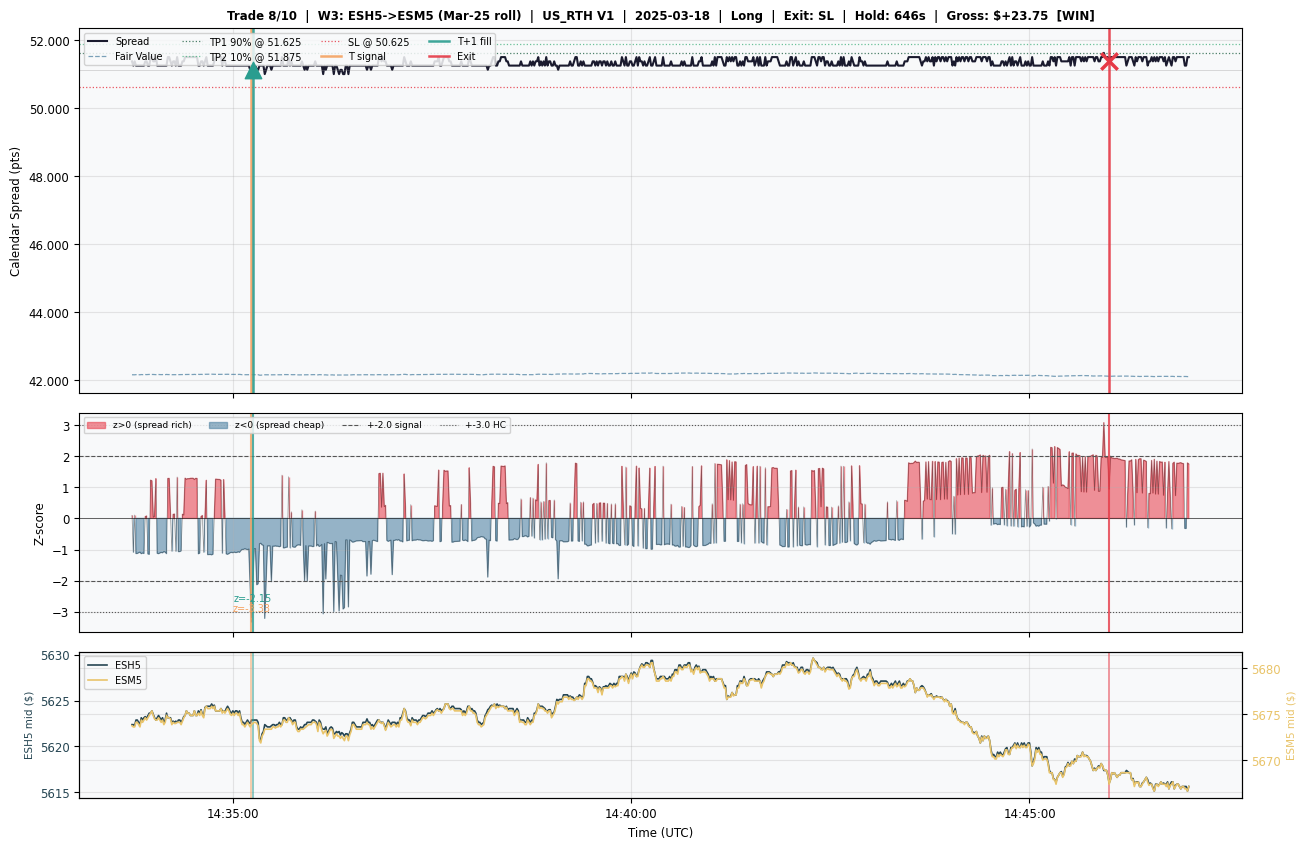


  Loading mbp10_ESM5_ESU5_2025-06-12_2025-06-12.parquet ... 

done.

  TRADE 9/10  |  W4: ESM5->ESU5 (Jun-25 roll)
  Session: European  |  Gate: V1  |  2025-06-12 Thursday

  T   (SIGNAL BAR)   12:03:39 UTC
  Spread          52.8750 pts
  Fair Value      44.4978 pts
  Deviation       +8.3772 pts  (spread - FV)
  Z-score         -2.7387  |  Rolling sigma ~ 3.0588 pts/z-unit
  ESM5          5993.3750    |  ESU5: 6046.2500
  --> Signal FIRES: z=-2.74 exceeds -2.0
      LONG: spread is +8.3772 pts (-2.7 sigma) BELOW fair value.
      Model expects mean-reversion upward.

  T+1 (FILL BAR)     12:03:40 UTC
  Entry spread      53.0000 pts  (midprice at T+1 bar)
  Z at fill         -1.4393
  ESM5            5993.3750    |  ESU5: 6046.3750
  --> ENTERED LONG at 53.0000  (10 lots)
  Market order executed at T+1 midprice.  (drift gate ALLOWED this direction)
  Low-z trade: |entry_z|=1.44 < 2.0  ->  single layer 100% TP at +0.25 pts; SL at -0.50 pts
  Not HC: |z_fill|=1.44 <= 3.0  ->  no add-on watch

  T+2 (ADD-ON BAR)   12:03:41 UTC
  Not applicable (HC wa

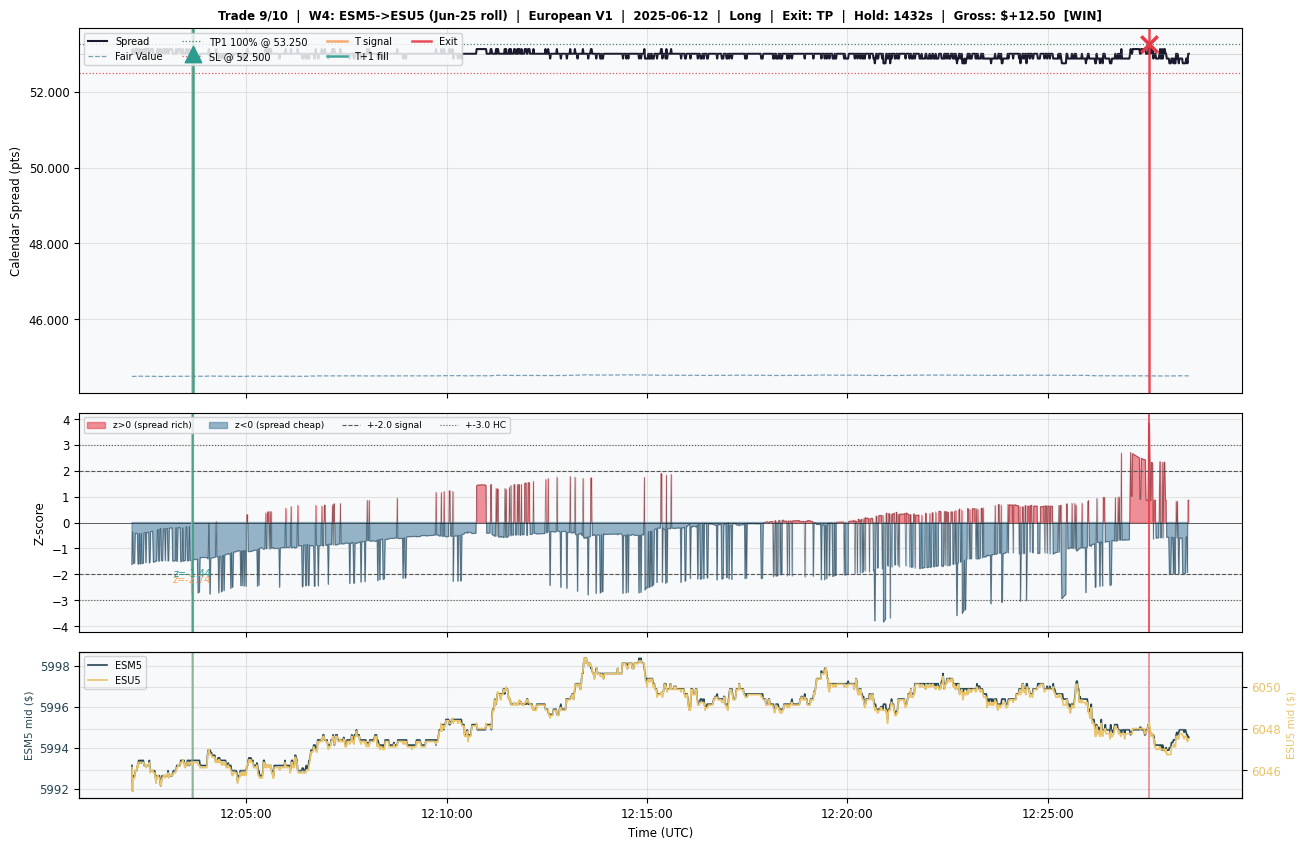


  Loading mbp10_ESH5_ESM5_2025-03-13_2025-03-17.parquet ... 

done.

  TRADE 10/10  |  W3: ESH5->ESM5 (Mar-25 roll)
  Session: US_RTH  |  Gate: V1  |  2025-03-17 Monday

  T   (SIGNAL BAR)   13:31:47 UTC
  Spread          52.5000 pts
  Fair Value      42.4485 pts
  Deviation      +10.0515 pts  (spread - FV)
  Z-score         +2.9075  |  Rolling sigma ~ 3.4571 pts/z-unit
  ESH5          5641.6250    |  ESM5: 5694.1250
  --> Signal FIRES: z=+2.91 exceeds +2.0
      SHORT: spread is +10.0515 pts (+2.9 sigma) ABOVE fair value.
      Model expects mean-reversion downward.

  T+1 (FILL BAR)     13:31:48 UTC
  Entry spread      52.3750 pts  (midprice at T+1 bar)
  Z at fill         +1.8696
  ESH5            5641.0000    |  ESM5: 5693.3750
  --> ENTERED SHORT at 52.3750  (10 lots)
  Market order executed at T+1 midprice.  (drift gate ALLOWED this direction)
  Low-z trade: |entry_z|=1.87 < 2.0  ->  single layer 100% TP at +0.25 pts; SL at -0.50 pts
  Not HC: |z_fill|=1.87 <= 3.0  ->  no add-on watch

  T+2 (ADD-ON BAR)   13:31:49 UTC
  Not applicable (HC 

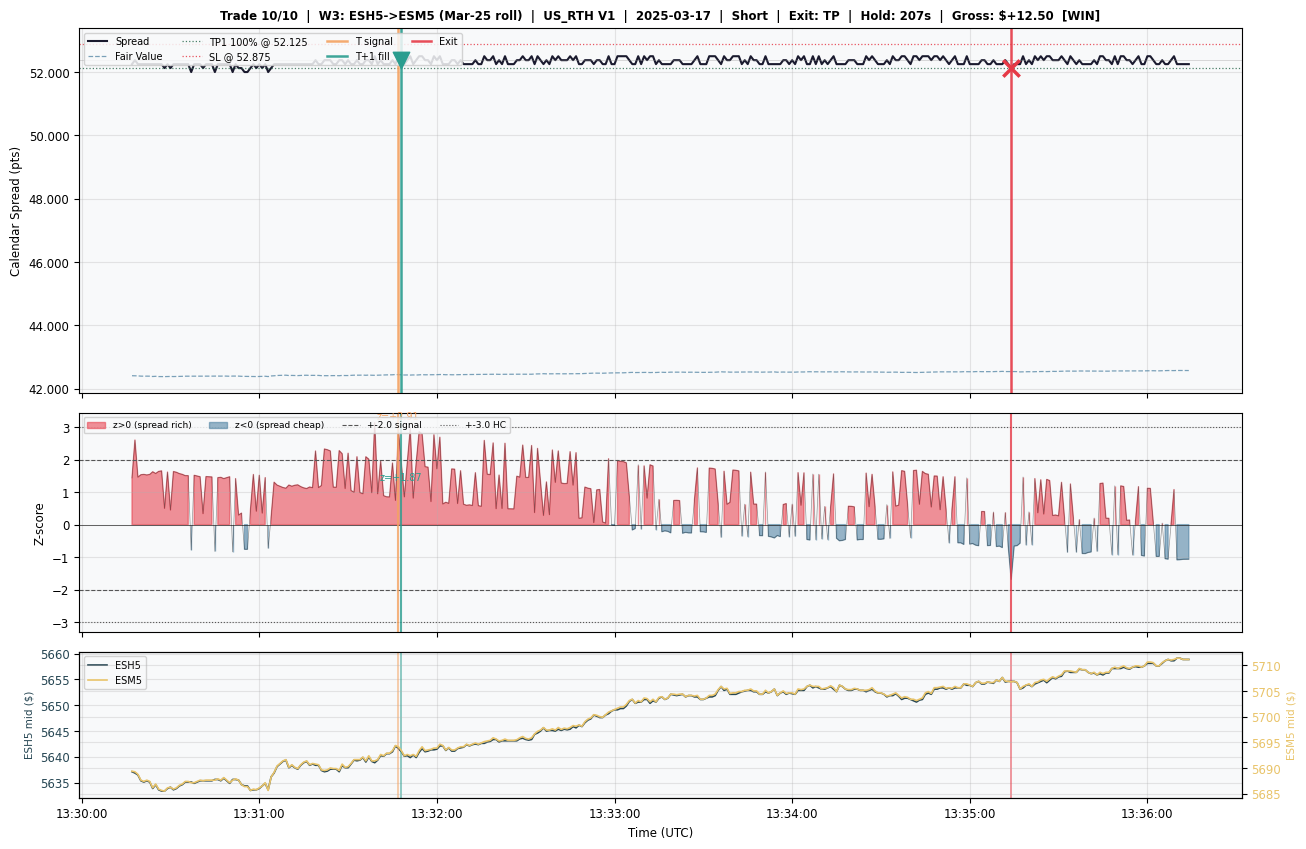

In [3]:
def analyze_trade(row, trade_num):
    wk       = row["window"]
    wi       = OOS[wk]
    sess     = row["session"]
    gate     = row["gate"]
    slabel   = row["sess_label"]

    entry_time = pd.Timestamp(row["entry_time"])
    exit_time  = pd.Timestamp(row["exit_time"])
    sig_time   = entry_time - pd.Timedelta("1s")   # T  (signal bar)
    addon_time = entry_time + pd.Timedelta("1s")   # T+2 (add-on bar)

    d          = int(row["direction"])              # +1=Long, -1=Short
    dir_label  = row["dir_label"]
    entry_z    = float(row["entry_z"])
    entry_z2   = row["entry_z2"]                   # NaN unless |z_fill|>Z_HC
    hc_addon   = bool(row["hc_addon"])
    lot_scale  = float(row["lot_scale"])
    lots_actual = int(N_LOTS * lot_scale)
    is_low_z   = abs(entry_z) < Z_SIG
    is_hc_cand = pd.notna(entry_z2)               # HC watch was set at fill

    entry_px   = float(row["entry_spread"])
    exit_px    = float(row["exit_spread"])

    # TP / SL levels
    if is_low_z:
        tps = [(entry_px + d * 0.25, "100%", 0.25)]
        sl  = entry_px - d * 0.50
    else:
        tps = [(entry_px + d * 0.50, "90%",  0.50),
               (entry_px + d * 0.75, "10%",  0.75)]
        sl  = entry_px - d * 0.50

    # ── Timeseries ───────────────────────────────────────────────────────────
    ts_df     = load_ts(wi["wdir"], slabel)
    ctx_start = sig_time   - pd.Timedelta("90s")
    ctx_end   = min(exit_time + pd.Timedelta("60s"), ts_df.index.max())
    ctx       = ts_df.loc[ctx_start:ctx_end].copy()

    sig_bar   = ts_at(ts_df, sig_time)
    fill_bar  = ts_at(ts_df, entry_time)
    addon_bar = ts_at(ts_df, addon_time)

    def _safe(bar, col):
        if bar is None: return np.nan
        try:    return float(bar[col])
        except: return np.nan

    sig_z     = _safe(sig_bar, "zscore")
    sig_sp    = _safe(sig_bar, "spread")
    sig_fv    = _safe(sig_bar, "fv")
    sig_dev   = _safe(sig_bar, "dev")
    sig_sigma = abs(sig_dev / sig_z) if (pd.notna(sig_z) and sig_z != 0) else np.nan

    fill_sp   = _safe(fill_bar, "spread")    # T+1 mid (for HC blended calc)
    addon_z   = _safe(addon_bar, "zscore")
    addon_sp  = _safe(addon_bar, "spread")   # T+2 mid price

    # ── MBP10 underlying prices ───────────────────────────────────────────────
    date_str = entry_time.date().isoformat()
    m        = load_mbp(wi["pair"], wi["roll_start"], date_str)

    front_sig,   back_sig   = lvcf(m["front"], sig_time),   lvcf(m["back"], sig_time)
    front_fill,  back_fill  = lvcf(m["front"], entry_time), lvcf(m["back"], entry_time)
    front_exit,  back_exit  = lvcf(m["front"], exit_time),  lvcf(m["back"], exit_time)
    front_addon, back_addon = lvcf(m["front"], addon_time), lvcf(m["back"], addon_time)

    front_ctx = m["front"].reindex(ctx.index, method="ffill")
    back_ctx  = m["back"].reindex(ctx.index, method="ffill")

    # ── Text breakdown ────────────────────────────────────────────────────────
    BAR = "=" * 72
    print(f"\n{BAR}")
    print(f"  TRADE {trade_num}/10  |  {wk}: {wi['label']}")
    print(f"  Session: {sess}  |  Gate: {gate}  |  {entry_time.strftime('%Y-%m-%d %A')}")
    print(BAR)

    print(f"\n  T   (SIGNAL BAR)   {sig_time.strftime('%H:%M:%S')} UTC")
    print(f"  {'Spread':12s} {sig_sp:>10.4f} pts")
    print(f"  {'Fair Value':12s} {sig_fv:>10.4f} pts")
    print(f"  {'Deviation':12s} {sig_dev:>+10.4f} pts  (spread - FV)")
    print(f"  {'Z-score':12s} {sig_z:>+10.4f}  |  Rolling sigma ~ {sig_sigma:.4f} pts/z-unit")
    print(f"  {wi['front']:12s} {front_sig:>10.4f}    |  {wi['back']}: {back_sig:.4f}")
    if d == -1:
        print(f"  --> Signal FIRES: z={sig_z:+.2f} exceeds +{Z_SIG:.1f}")
        print(f"      SHORT: spread is {sig_dev:+.4f} pts ({sig_z:+.1f} sigma) ABOVE fair value.")
        print(f"      Model expects mean-reversion downward.")
    else:
        print(f"  --> Signal FIRES: z={sig_z:+.2f} exceeds -{Z_SIG:.1f}")
        print(f"      LONG: spread is {sig_dev:+.4f} pts ({sig_z:+.1f} sigma) BELOW fair value.")
        print(f"      Model expects mean-reversion upward.")

    print(f"\n  T+1 (FILL BAR)     {entry_time.strftime('%H:%M:%S')} UTC")
    print(f"  {'Entry spread':14s} {entry_px:>10.4f} pts  (midprice at T+1 bar)")
    print(f"  {'Z at fill':14s} {entry_z:>+10.4f}")
    print(f"  {wi['front']:14s} {front_fill:>10.4f}    |  {wi['back']}: {back_fill:.4f}")
    print(f"  --> ENTERED {dir_label.upper()} at {entry_px:.4f}  ({lots_actual} lots)")

    gate_note = "(drift gate ALLOWED this direction)" if gate == "V1" else "(no gate on baseline)"
    print(f"  Market order executed at T+1 midprice.  {gate_note}")

    if is_low_z:
        print(f"  Low-z trade: |entry_z|={abs(entry_z):.2f} < {Z_SIG}  ->  single layer 100% TP at +0.25 pts; SL at -0.50 pts")
    else:
        print(f"  Standard-z: |entry_z|={abs(entry_z):.2f} >= {Z_SIG}  ->  two-layer exit (90%@+0.50, 10%@+0.75)")

    if is_hc_cand:
        print(f"  HC WATCH SET: |z_fill|={abs(entry_z):.2f} > {Z_HC}  ->  checking T+2 bar")
    else:
        print(f"  Not HC: |z_fill|={abs(entry_z):.2f} <= {Z_HC}  ->  no add-on watch")

    print(f"\n  T+2 (ADD-ON BAR)   {addon_time.strftime('%H:%M:%S')} UTC")
    if is_hc_cand:
        ez2 = float(entry_z2)
        print(f"  Z at T+2:  {ez2:+.4f}")
        if hc_addon:
            blended = entry_px   # stored blended entry IS row['entry_spread'] for HC trades
            orig_fill = fill_sp  # T+1 midprice (pre-blend) from timeseries
            print(f"  |z|={abs(ez2):.2f} > {Z_HC}  ->  ADD-ON TRIGGERED")
            print(f"  Original T+1 fill:  {orig_fill:.4f}")
            print(f"  Add-on at T+2 mid:  {addon_sp:.4f}")
            print(f"  Blended entry:      ({orig_fill:.4f} + {addon_sp:.4f}) / 2 = {blended:.4f}  (stored in trade)")
            print(f"  Total lots now:     {lots_actual}  ({N_LOTS} base + {N_LOTS} add-on)")
            print(f"  {wi['front']:14s} {front_addon:>10.4f}    |  {wi['back']}: {back_addon:.4f}")
        else:
            print(f"  |z|={abs(ez2):.2f} <= {Z_HC}  ->  z retreated; add-on NOT fired")
            print(f"  Remaining at {N_LOTS} lots with original entry {entry_px:.4f}")
    else:
        print(f"  Not applicable (HC watch was not set at T+1 fill)")

    print(f"\n  POSITION STRUCTURE")
    print(f"  Lots: {lots_actual}  |  Lot scale: {lot_scale:.1f}x  |  $50/pt/lot")
    for tp_px, pct, tp_pts in tps:
        layer_note = ""
        if not is_low_z and pct == "90%": layer_note = "  [SL -> BE after hit]"
        if not is_low_z and pct == "10%": layer_note = "  [SL -> +0.50 after TP1]"
        print(f"  Layer {pct:4s}: TP at {tp_px:.4f}  (+{tp_pts:.2f} pts){layer_note}")
    print(f"  Initial SL:   {sl:.4f}  (-0.50 pts from entry)")

    print(f"\n  EXIT   {exit_time.strftime('%H:%M:%S')} UTC  [{row['exit_type']}]")
    print(f"  {'Exit spread':14s} {exit_px:>10.4f} pts")
    print(f"  {wi['front']:14s} {front_exit:>10.4f}    |  {wi['back']}: {back_exit:.4f}")
    print(f"  Hold time:     {row['bars_held']} bars  ({row['hold_min']:.1f} min)")
    print(f"  Layers hit:    {row['layers_hit']}")
    print(f"  MAE:           {row['mae_pts']:+.4f} pts  (max adverse excursion from entry)")
    print(f"  MFE:           {row['mfe_pts']:+.4f} pts  (max favorable excursion from entry)")
    print(f"  Gross:         {row['gross_pts']:+.4f} pts  =  ${row['gross_usd']:+.2f} per 10-lot-equiv")
    print(f"  Net (Mid TC):  ${row['net_Mid']:+.2f}")
    outcome = "WIN" if row["gross_usd"] > 0 else ("SCRATCH" if row["gross_usd"] == 0 else "LOSS")
    print(f"  Outcome:       {outcome}")

    # ── Chart ─────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(15, 10))
    gs  = gridspec.GridSpec(3, 1, hspace=0.08, height_ratios=[5, 3, 2])
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax3 = fig.add_subplot(gs[2], sharex=ax1)

    xt = ctx.index

    # --- ax1: Spread + FV ---
    ax1.plot(xt, ctx["spread"], color="#1a1a2e", lw=1.5, label="Spread")
    ax1.plot(xt, ctx["fv"],     color="#457b9d", lw=0.9, ls="--", alpha=0.7, label="Fair Value")

    # TP/SL horizontals
    tp_clrs = ["#2d6a4f", "#52b788"]
    for i, (tp_px, pct, tp_pts) in enumerate(tps):
        ax1.axhline(tp_px, color=tp_clrs[i], lw=0.9, ls=":", alpha=0.85,
                    label=f"TP{i+1} {pct} @ {tp_px:.3f}")
    ax1.axhline(sl, color="#e63946", lw=0.9, ls=":", alpha=0.85, label=f"SL @ {sl:.3f}")
    ax1.axhline(entry_px, color="#888", lw=0.6, ls="-", alpha=0.35)

    # Key time verticals
    ax1.axvline(sig_time,  color="#f4a261", lw=1.8, alpha=0.9, label="T signal")
    ax1.axvline(entry_time, color="#2a9d8f", lw=1.8, alpha=0.9, label="T+1 fill")
    ax1.axvline(exit_time,  color="#e63946", lw=1.8, alpha=0.9, label="Exit")
    if hc_addon:
        ax1.axvline(addon_time, color="#9b2226", lw=1.8, ls="--", alpha=0.9, label="T+2 add-on")

    # Entry / exit markers
    ax1.scatter([entry_time], [entry_px],
                marker="^" if d == 1 else "v", color="#2a9d8f", s=140, zorder=6)
    ax1.scatter([exit_time],  [exit_px],
                marker="x", color="#e63946", s=140, zorder=6, linewidths=2.5)

    ax1.set_ylabel("Calendar Spread (pts)")
    outcome_short = "WIN" if row["gross_usd"] > 0 else ("SCRATCH" if row["gross_usd"] == 0 else "LOSS")
    ax1.set_title(
        f"Trade {trade_num}/10  |  {wk}: {wi['label']}  |  {sess} {gate}  |  "
        f"{entry_time.strftime('%Y-%m-%d')}  |  {dir_label}  |  "
        f"Exit: {row['exit_type']}  |  Hold: {row['bars_held']}s  |  "
        f"Gross: ${row['gross_usd']:+.2f}  [{outcome_short}]",
        fontsize=8.5, fontweight="bold"
    )
    ax1.legend(loc="upper left", fontsize=7, ncol=4, framealpha=0.85)
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    plt.setp(ax1.get_xticklabels(), visible=False)

    # --- ax2: Z-score ---
    ax2.fill_between(xt, 0, ctx["zscore"],
                     where=ctx["zscore"] > 0, color="#e63946", alpha=0.55, label="z>0 (spread rich)")
    ax2.fill_between(xt, 0, ctx["zscore"],
                     where=ctx["zscore"] <= 0, color="#457b9d", alpha=0.55, label="z<0 (spread cheap)")
    ax2.plot(xt, ctx["zscore"], color="black", lw=0.5, alpha=0.4)
    for thresh, ls, lbl in [(Z_SIG, "--", f"+-{Z_SIG} signal"), (Z_HC, ":", f"+-{Z_HC} HC")]:
        ax2.axhline( thresh, color="#555", lw=0.8, ls=ls, label=lbl)
        ax2.axhline(-thresh, color="#555", lw=0.8, ls=ls)
    ax2.axhline(0, color="black", lw=0.4)
    ax2.axvline(sig_time,   color="#f4a261", lw=1.5, alpha=0.8)
    ax2.axvline(entry_time, color="#2a9d8f", lw=1.5, alpha=0.8)
    ax2.axvline(exit_time,  color="#e63946", lw=1.5, alpha=0.8)
    if hc_addon:
        ax2.axvline(addon_time, color="#9b2226", lw=1.5, ls="--", alpha=0.8)

    # Annotate key z values
    if pd.notna(sig_z):
        ax2.annotate(f"z={sig_z:+.2f}", xy=(sig_time, sig_z),
                     xytext=(0, 8), textcoords="offset points",
                     fontsize=7, ha="center", color="#f4a261",
                     arrowprops=dict(arrowstyle="-", color="#f4a261", lw=0.6))
    if pd.notna(entry_z):
        ax2.annotate(f"z={entry_z:+.2f}", xy=(entry_time, entry_z),
                     xytext=(0, -12), textcoords="offset points",
                     fontsize=7, ha="center", color="#2a9d8f",
                     arrowprops=dict(arrowstyle="-", color="#2a9d8f", lw=0.6))

    ax2.set_ylabel("Z-score")
    ax2.legend(loc="upper left", fontsize=6.5, ncol=4, framealpha=0.85)
    plt.setp(ax2.get_xticklabels(), visible=False)

    # --- ax3: Underlying front / back prices ---
    ax3b = ax3.twinx()
    if not front_ctx.dropna().empty:
        ax3.plot(front_ctx.index, front_ctx.values,
                 color="#264653", lw=1.2, label=wi["front"])
    if not back_ctx.dropna().empty:
        ax3b.plot(back_ctx.index, back_ctx.values,
                  color="#e9c46a", lw=1.2, label=wi["back"])
    ax3.set_ylabel(f"{wi['front']} mid ($)", color="#264653", fontsize=7.5)
    ax3b.set_ylabel(f"{wi['back']} mid ($)",  color="#e9c46a", fontsize=7.5)
    ax3.tick_params(axis="y", labelcolor="#264653")
    ax3b.tick_params(axis="y", labelcolor="#e9c46a")
    ax3.axvline(sig_time,   color="#f4a261", lw=1.2, alpha=0.6)
    ax3.axvline(entry_time, color="#2a9d8f", lw=1.2, alpha=0.6)
    ax3.axvline(exit_time,  color="#e63946", lw=1.2, alpha=0.6)
    if hc_addon:
        ax3.axvline(addon_time, color="#9b2226", lw=1.2, ls="--", alpha=0.6)
    handles = [
        Line2D([0],[0], color="#264653", lw=1.2, label=wi["front"]),
        Line2D([0],[0], color="#e9c46a", lw=1.2, label=wi["back"]),
    ]
    ax3.legend(handles=handles, loc="upper left", fontsize=7, framealpha=0.85)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax3.set_xlabel("Time (UTC)")

    plt.tight_layout()
    plt.show()
    print()


# ── Run analysis for all 10 sampled trades ────────────────────────────────────
for i, (_, row) in enumerate(sample.iterrows(), start=1):
    analyze_trade(row, i)
